# 1.Multi Armed Bandits

### 1.1 Теоретическая задача

Epsilon-greedy algorithm with exploration probabilities $\varepsilon = t^{-1/3} \cdot (K \log t)^{1/3}$

achieves regret bound $\mathbb{E} R(t) \leq t^{2/3} \cdot O(K \log t)^{1/3}$ for each round $t$.

[см.](https://arxiv.org/pdf/1904.07272) Theorem 1.6 & Algorithm 1.2


To find regret bound, we need to consider two bounds: for exploration and exploitation steps.

In $\varepsilon = t^{-1/3}(K \log t)^{1/3}$ cases, algorithm chooses random arm, and gives regret $\frac{1}{K} \sum_{i=1}^K (\mu(a^*) - \mu(a_i)) = C$. Total expected regret for all exploration steps is:
$$ \mathbb{E} R(T) = C \varepsilon = C \sum_{t=1}^T t^{-1/3}(K \log t)^{1/3} \approx C \int_0^T t^{-1/3}(K \log t)^{1/3} dx = C t^{2/3}(K \log t)^{1/3} = O(t^{2/3}(K \log t)^{1/3}) $$
 
In $1 - \varepsilon$ cases, algorithm chooses arm with maximum average reward. For large $t$, average rewards for each arm are close to their true means, giving 0 regret, but it accumulates some regret before that. Similarly to proof in Section 1.3.2, we can show using Hoeffding Inequality that accumulated regret is $O(\sqrt{t \log T})$, which is less than $O(t^{2/3}(K \log t)^{1/3})$ for large $t$, hence we can ignore it. The expected total regret is 
$$ \mathbb{E} R(t) = O(t^{2/3}(K \log t)^{1/3}) $$

### 1.2 Теоретическая задача

Take UCB bandit algorithm $A$ for fixed time horizon $T$ . Convert it to an algorithm $A_{\infty}$ which runs forever, in phases $i = 1, 2, 3, ...$ of $2^i$ rounds each.

In each phase $i$ algorithm $A$ is restarted and run with time horizon $2^i$.

State and prove a theorem which converts an instance-independent upper bound on regret for $A$ into similar bound for $A_{\infty}$.

[см.](https://arxiv.org/pdf/1904.07272) Chapter 1 & Algorithm 1.5

It is known that for UCB algorithm regret bound is $R(T) = O(\sqrt{T \log T})$, or $R(T) \leq C \sqrt{T \log T}$.

Then, for $A_{\infty}$ regret bound can be expressed as 
$$ R(T) \leq C \sum_{2^i-1 \leq T} \sqrt{2^i \log 2^i} $$
Where we sum upper bounds for every phase $i$ until sum of their length reaches $T$. For simplicity, use same constant $C = \max{C_i}$ for all phases. Note that we have at most $\lceil \log_2 T \rceil + 1 \leq C \log T$ phases, hence
$$ R(T) \leq C \sqrt{T \log T} \cdot \log T \iff $$ 
$$ R(T)= O(\sqrt{T} \log^{\frac{3}{2}} T) $$

### 1.3 Практическая задача

На первом семинаре разбирали метод $\varepsilon$ - greedy.

В этом задании предстоит дополнить MAB методом UCB в рамках того же класса MAB, что и рассматривали в семинаре.

Для определенности алгоритм можно посмотреть здесь **[см.](https://arxiv.org/pdf/1904.07272) Chapter 1 & Algorithm 1.5**

$UCB_i(t) = \sqrt{\frac{\delta \ln (T)}{t_i}}$

$\delta$ - параметр исследования, подберите самостоятельно

$T$ - временной горизонт

$t_i$ - сколько раз дергали ручку $i$ до шага $t$



In [1]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

"""

import numpy as np
from abc import ABC, abstractmethod

class MAB(ABC):
    """Base class for multi-armed bandit (MAB)

    Parameters
    ----------
    n_arms : int
        Number of arms.
    """
    # initialise
    def __init__(self, n_arms):
        self.n_arms = n_arms

    @abstractmethod
    def play(self):
        """Play a round

        Returns
        -------
        arm : int
            Integer index of the arm played this round. Should be in the set
            {0, ..., n_arms - 1}.
        """
        pass

    @abstractmethod
    def update(self, arm, reward):
        """Update the internal state of the MAB after a play

        Parameters
        ----------
        arm : int
            Integer index of the played arm in the set {0, ..., n_arms - 1}.

        reward : float
            Reward received from the arm.

        """
        self.arm = arm
        self.reward = reward


def offlineEvaluate(mab, true_bandit_probs, n_arms, n_rounds= 100000):
    """Offline evaluation of a multi-armed bandit

    Parameters
    ----------
    mab : instance of MAB
        MAB to evaluate.

    n_arms : int
        Number of arms.

    true_bandit_probs : float numpy.ndarray, shape (n_events,)
        Array containing the history of rewards.


    n_rounds : int, default=None
        Number of matching events to evaluate the MAB on.

    Returns
    -------
    R : float numpy.ndarray
        Rewards for the matching events.

    H : int numpy.ndarray
        Historical events
    """

    R = []          # save the total payoff
    H = np.zeros((n_rounds, n_arms)) # save used historical events

    for i in range(n_rounds):
        arm = mab.play()
        reward = np.random.rand() < true_bandit_probs[arm]

        R.append(reward)  # append the new rewards
        H[i, arm] = 1     # append the used events

        mab.update(arm, reward) # update the information

    return np.array(R), np.array(H)

In [2]:
"""
реализуем класс UCB по аналогии с EpsGreedy(MAB) первого семинара

необходимые каунтеры можете использовать такие же как в EpsGreedy или завести свои

"""


class UCB(MAB):
    """UCB multi-armed bandit

    Parameters
    ----------

    """

    # initialise values
    def __init__(self, n_arms, param):
        super().__init__(n_arms)
        self.delta, self.T = param
        self.arm_counts = np.zeros(n_arms)
        self.arm_sums = np.zeros(n_arms)
        self.n_iterations = 0

    def play(self):
        if self.n_iterations < self.n_arms * 3:
            arm = self.n_iterations % self.n_arms
            self.n_iterations += 1

        else:
            ucb_values = self.arm_sums / self.arm_counts + np.sqrt(
                self.delta * np.log(self.T) / self.arm_counts
            )
            lcb_values = self.arm_sums / self.arm_counts - np.sqrt(
                self.delta * np.log(self.T) / self.arm_counts
            )
            deactivation = np.where(ucb_values <= np.max(lcb_values), np.inf, 0)
            ucb_values -= deactivation
            arm = np.argmax(ucb_values)

        return arm

    def update(self, arm, reward):
        self.arm_counts[arm] += 1
        self.arm_sums[arm] += reward

In [3]:
"""
Заведем бандита с 4 ручками и распределением выигрышей ручек [0.45, 0.35, 0.85, 0.62]

На временном горизонте 100000

Подбираем параметр исследования (delta), который согласуется с теоретическим в оценке регрета

"""
n_arms = 4
n_iterations = 100000
true_bandit_probs = np.array([0.45, 0.35, 0.85, 0.62])
param = (0.5, n_iterations)


In [4]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

запускаем процесс

"""
mab = UCB(n_arms, param)
results_UCB, history_UCB = offlineEvaluate(mab, true_bandit_probs, n_arms, n_iterations)
print('UCB average reward', np.mean(results_UCB))

UCB average reward 0.84863


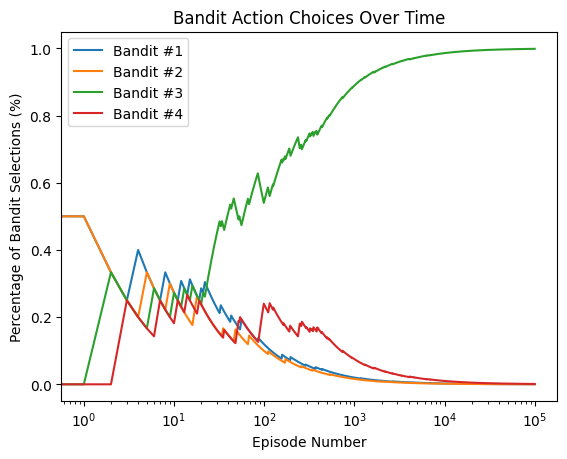

Bandit #1 -> 0.45
Bandit #2 -> 0.35
Bandit #3 -> 0.85
Bandit #4 -> 0.62


In [5]:
import matplotlib.pyplot as plt
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

посмотрим на динамику выбора ручек
"""

selections_percentage = np.cumsum(history_UCB, axis=0) / np.arange(1, n_iterations + 1).reshape(-1, 1)

for arm in range(n_arms):
    plt.plot(selections_percentage[:, arm], label=f'Bandit #{arm+1}')
plt.xscale('log')
plt.title('Bandit Action Choices Over Time')
plt.xlabel('Episode Number')
plt.ylabel('Percentage of Bandit Selections (%)')
plt.legend()
plt.show()
for i, prob in enumerate(true_bandit_probs, 1):
    print(f"Bandit #{i} -> {prob:.2f}")

# 2.Expert Advice.


###2.1 Теоретическая задача

Sequences of outcomes on which many experts suffer a small loss are
intuitively easier to predict. Show that the **exponentially weighted forecaster** satistifies the following property: for every $n$, for every outcome sequence $y_n$ , and for all $L > 0$,
$$\hat L_n ≤ L + \frac{1}{\mu}\ln\frac{N}{N_L} + \frac{\mu}{8}n$$
where $N_L$ is the cardinality of the set $\{1 \leq i \leq N : L_{i,n} \leq L\}$
### --------------------------------------------------------------------------------------------------------------------------------------------------

Exponentially Weighted Forecaster based on the
potential $\Phi_{\mu}(\mathbf{u})= \frac{1}{\mu} \ln(\sum_{i=1}^N e^{\mu u_i}) $ where $\mu>0$.

$N$ - number of experts.

$n$ - number of times.

$L_{i, n} = \sum_{t=1}^n\ell(f_{i, t}, y_t)$ - cumulative loss of expert $i$

 $\hat L_{n} = \sum_{t=1}^n \ell(\hat p_t, y_t)$ - cumulative loss of forecaster.

**[см ](https://ece.iisc.ac.in/~aditya/Prediction_Learning_and_Games.pdf)Corollary 2.2.**

From Theorem 2.2 we know that $\log \frac{W_n}{W_0} \leq -\mu \hat{L}_n + \frac{\mu^2}{8}n$, where $W_n = \sum_{i=1}^{N} \exp(-\mu L_{i,n})$. We can lower bound $W_n$ in terms of $L$ and $N_L$:
$$ W_n \geq \sum_{L_{i,n} \leq L} \exp(-\mu L_{i,n}) \geq \sum_{L_{i,n} \leq L} \exp(-\mu L) = N_L \exp(-\mu L) $$
Now we substitute this into the inequality:
$$ \log \frac{N_L \exp(-\mu L)}{W_0} \leq -\mu \hat{L}_n + \frac{\mu^2}{8}n \iff $$
$$ \log N_L - \mu L - \log N \leq -\mu \hat{L}_n + \frac{\mu^2}{8}n \iff $$
$$ \hat{L}_n \leq L + \frac{1}{\mu} \log \frac{N}{N_L} + \frac{\mu}{8}n $$

### 2.2 Практическая задача

В этом задании предстоит реализовать exponentially weighted forecaster  по аналогии с polynomially-weighted forecaster второго семинара. И сравнить теоретический и реализованный регреты.

Нужно определить потенциальную функцию и лосс, подсчитать реализованный и теоретический регреты.

**param** выступает в роли параметра метода. Для polynomially-weighted forecaster параметр отвечал за значение степени нормы $p$. Для exponentially weighted forecaster параметр отвечает за $\mu$.

Параметр $\mu$ подберите самостоятельно.

В res функции **step** записываются необходимые результаты для подсчета реализованного регрета


In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


In [7]:
"""

Определим лосс и потенциал для экспотенциального взвешивания

"""


def loss(yhat, y):
    return (yhat - y) ** 2


def potential(x, param):
    return jnp.log(jnp.sum(jnp.exp(param * x))) / param


gradp = jax.grad(potential)  # функция градиента


In [8]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

"""


@partial(jax.vmap, in_axes=(0, 0, None), out_axes=-1)
def _create_mistakes(key, p, T):
    mistakes = jax.random.bernoulli(key, p=p, shape=(T,))
    return mistakes


def bern_oracle_beta_forecasters(
    key, n_experts, n_timesteps, a_fcst=2, b_fsct=7, p_oracle=0.5
):
    """
    Create a set of forecasters whose probability of being correct is
    distributed according to a Beta(a_fcst, b_fcst) distribution.
    The oracle is a Bernoulli random variable with p=p_oracle.
    """
    key_oracle, key_noise, key_errs = jax.random.split(key, 3)
    keys_noise = jax.random.split(key_noise, n_experts)

    oracle = jax.random.bernoulli(key_oracle, p=p_oracle, shape=(n_timesteps,))
    ps_mistakes = jax.random.beta(key_errs, a=a_fcst, b=b_fsct, shape=(n_experts,))

    mistakes = _create_mistakes(keys_noise, ps_mistakes, n_timesteps)
    experts = (mistakes ^ oracle[:, None]).astype(float)

    return oracle, experts


def forecast_step(experts_curr, regret_prev, param):
    weights = gradp(regret_prev, param)
    forecast = weights @ experts_curr / weights.sum()
    return weights, forecast


def step(regret, xs, param):
    """
    At time t, we make a prediction based on the
    regret (as defined by the potential) obtained at time
    t-1 and the prediction of each forecaster at time t.

    After making a new prediction, we update the regret.
    """
    experts, oracle = xs
    weights, forecast = forecast_step(experts, regret, param)

    loss_forecaster = loss(forecast, oracle)
    loss_experts = loss(experts, oracle)

    iregret_experts = loss_forecaster - loss_experts

    regret_new = regret + iregret_experts

    res = {
        "weights": weights,
        "forecast": forecast,
        "step-loss-experts": loss_experts,
        "step-loss-forecaster": loss_forecaster,
    }

    return regret_new, res

In [9]:
"""
генерим ответы природы (oracle) ~ Bernoulli(0.7) и ошибки 10 экспертов (experts) ~  Beta(3,3)
c помощью bern_oracle_beta_forecasters()

подбираем временной горизонт

"""

key = jax.random.PRNGKey(314)


n_experts = 10
n_timesteps = 1000

param = jnp.sqrt(2 * jnp.log(n_experts) / n_timesteps)

a, b = 2, 7  # параметры распределения Beta
p_oracle = 0.5  # параметры распределения  Bernoulli


oracle, experts = bern_oracle_beta_forecasters(
    key=key,
    n_experts=n_experts,
    n_timesteps=n_timesteps,
    a_fcst=a,
    b_fsct=b,
    p_oracle=p_oracle,
)


In [10]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

запускаем процесс
"""

regret = jnp.ones(n_experts)

xs = (experts, oracle)

part_step = partial(step, param=param)
_, res = jax.lax.scan(part_step, regret, xs)

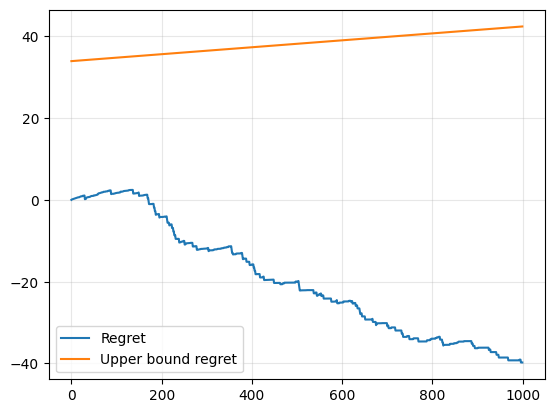

In [11]:
"""
построим  график реализованного и теоретического регретов

необходимые значения можно получить из результатов res
"""
L_experts = res["step-loss-experts"].cumsum(axis=0)
L_expert_min = L_experts.min(axis=1)
L_forecaster = res["step-loss-forecaster"].cumsum()

regret_forecaster = L_forecaster - L_expert_min
timesteps = jnp.arange(n_timesteps)
regret_ubound = jnp.log(n_experts) / param + param * timesteps / 8 

plt.plot(regret_forecaster, label="Regret")
plt.plot(regret_ubound, label="Upper bound regret")
plt.legend()
plt.grid(alpha=0.3)